In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df_raw = pd.read_csv('../Anexos/Data_Caso_Propuesto.csv')
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 463 entries, 0 to 462
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Codigo                  463 non-null    int64  
 1   Ciudad                  463 non-null    str    
 2   Departamento            463 non-null    str    
 3   Barrio                  40 non-null     str    
 4   Direccion               463 non-null    str    
 5   Area Terreno            463 non-null    float64
 6   Area Construida         463 non-null    float64
 7   Detalle Disponibilidad  463 non-null    str    
 8   Estrato                 463 non-null    str    
 9   Precio                  463 non-null    float64
 10  Tipo de Inmueble        463 non-null    str    
 11  Datos Adicionales       118 non-null    str    
dtypes: float64(3), int64(1), str(8)
memory usage: 43.5 KB


In [77]:
df_raw.head(5)

,Codigo,Ciudad,Departamento,Barrio,Direccion,Area Terreno,Area Construida,Detalle Disponibilidad,Estrato,Precio,Tipo de Inmueble,Datos Adicionales
0,17180,BOGOTA,CUNDINAMARCA,NaN,AV CR 7 NO. 166 - 51 LT B,0.00,0.0,COMERCIALIZABLE CON RESTRICCION,TRES,2.958081e+10,LOTE COMERCIAL,ESTE INMUEBLE SE COMERCIALIZARÁ A TRAVES DE SU...
1,19292,BOGOTA,CUNDINAMARCA,NaN,CL 72 No. 12 - 77,0.00,0.0,COMERCIALIZABLE,COMERCIAL,1.646059e+10,EDIFICIO,NaN
2,19292,BOGOTA,CUNDINAMARCA,NaN,CL 72 No. 12 - 77,0.00,0.0,COMERCIALIZABLE VENTA ANTICIPADA,COMERCIAL,1.646059e+10,EDIFICIO,NaN
3,2575,SOGAMOSO,BOYACÁ,CENTRO,CRA. 10 #11- 78/80 Ó CL 12 # 9 - 77/85 Ó CALLE...,1655.08,7269.0,COMERCIALIZABLE CON RESTRICCION,CUATRO,1.376828e+10,CLINICA,ESTE INMUEBLE SE COMERCIALIZARÁ A TRAVÉS DE SU...
4,11409,BUGA,VALLE DEL CAUCA,VEREDA CHAMBIMBAL,LT A1-A24 B1-B79 C1-C51 D1-D9 STA ROSA LT1-46 ...,3217197.00,22724.0,COMERCIALIZABLE FIDUCIA,RURAL,4.523379e+10,LOTE MIXTO,NaN


In [5]:
df_raw.isnull().sum()

Codigo                      0
Ciudad                      0
Departamento                0
Barrio                    423
Direccion                   0
Area Terreno                0
Area Construida             0
Detalle Disponibilidad      0
Estrato                     0
Precio                      0
Tipo de Inmueble            0
Datos Adicionales         345
dtype: int64

In [76]:
df_raw.duplicated().value_counts()

False    463
Name: count, dtype: int64

In [11]:
df = df_raw.copy()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 463 entries, 0 to 462
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Codigo                  463 non-null    int64  
 1   Ciudad                  463 non-null    str    
 2   Departamento            463 non-null    str    
 3   Barrio                  40 non-null     str    
 4   Direccion               463 non-null    str    
 5   Area Terreno            463 non-null    float64
 6   Area Construida         463 non-null    float64
 7   Detalle Disponibilidad  463 non-null    str    
 8   Estrato                 463 non-null    str    
 9   Precio                  463 non-null    float64
 10  Tipo de Inmueble        463 non-null    str    
 11  Datos Adicionales       118 non-null    str    
dtypes: float64(3), int64(1), str(8)
memory usage: 43.5 KB


In [12]:
df = df.drop(columns=['Barrio', 'Datos Adicionales'])

In [13]:
df[df.duplicated(subset=['Codigo'], keep=False)]

,Codigo,Ciudad,Departamento,Direccion,Area Terreno,Area Construida,Detalle Disponibilidad,Estrato,Precio,Tipo de Inmueble
1,19292,BOGOTA,CUNDINAMARCA,CL 72 No. 12 - 77,0.0,0.0,COMERCIALIZABLE,COMERCIAL,1.646059e+10,EDIFICIO
2,19292,BOGOTA,CUNDINAMARCA,CL 72 No. 12 - 77,0.0,0.0,COMERCIALIZABLE VENTA ANTICIPADA,COMERCIAL,1.646059e+10,EDIFICIO
61,19210,BARRANQUILLA,ATLÁNTICO,CR 51 B No. 76-136 ED CENTRO EMPRESARIAL LA PR...,0.0,0.0,COMERCIALIZABLE,SEIS,2.221325e+08,OFICINA
62,19210,BARRANQUILLA,ATLÁNTICO,CR 51 B No. 76-136 ED CENTRO EMPRESARIAL LA PR...,0.0,0.0,COMERCIALIZABLE VENTA ANTICIPADA,SEIS,2.221325e+08,OFICINA
64,19209,BARRANQUILLA,ATLÁNTICO,CR 51 B No. 76-136 ED CENTRO EMPRESARIAL LA PR...,0.0,0.0,COMERCIALIZABLE,SEIS,2.132058e+08,OFICINA
65,19209,BARRANQUILLA,ATLÁNTICO,CR 51 B No. 76-136 ED CENTRO EMPRESARIAL LA PR...,0.0,0.0,COMERCIALIZABLE VENTA ANTICIPADA,SEIS,2.132058e+08,OFICINA
66,19211,BARRANQUILLA,ATLÁNTICO,CR 51 B No. 76-136 ED CENTRO EMPRESARIAL LA PR...,0.0,0.0,COMERCIALIZABLE,SEIS,2.132058e+08,OFICINA
67,19211,BARRANQUILLA,ATLÁNTICO,CR 51 B No. 76-136 ED CENTRO EMPRESARIAL LA PR...,0.0,0.0,COMERCIALIZABLE VENTA ANTICIPADA,SEIS,2.132058e+08,OFICINA
70,19212,BARRANQUILLA,ATLÁNTICO,CR 51 B No. 76-136 ED CENTRO EMPRESARIAL LA PR...,0.0,0.0,COMERCIALIZABLE,SEIS,1.861440e+08,OFICINA
71,19212,BARRANQUILLA,ATLÁNTICO,CR 51 B No. 76-136 ED CENTRO EMPRESARIAL LA PR...,0.0,0.0,COMERCIALIZABLE VENTA ANTICIPADA,SEIS,1.861440e+08,OFICINA


In [14]:
# 1. Identificar los codigos duplicados del dataset
codigos_duplicados = df[df.duplicated(subset=['Codigo'], keep=False)]['Codigo'].unique()

# 2. Definir la condicion exacta de las filas a Eliminar
condicion_eliminar = ((df['Codigo'].isin(codigos_duplicados)) & (df['Detalle Disponibilidad'] == 'COMERCIALIZABLE VENTA ANTICIPADA'))

# 3. Conservar las filas que no cumplen esa condicion
df = df[~condicion_eliminar]

df.info()

<class 'pandas.DataFrame'>
Index: 456 entries, 0 to 462
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Codigo                  456 non-null    int64  
 1   Ciudad                  456 non-null    str    
 2   Departamento            456 non-null    str    
 3   Direccion               456 non-null    str    
 4   Area Terreno            456 non-null    float64
 5   Area Construida         456 non-null    float64
 6   Detalle Disponibilidad  456 non-null    str    
 7   Estrato                 456 non-null    str    
 8   Precio                  456 non-null    float64
 9   Tipo de Inmueble        456 non-null    str    
dtypes: float64(3), int64(1), str(6)
memory usage: 39.2 KB


In [17]:
df['Precio_Millones'] = df['Precio'] / 1_000_000
df.head(5)

,Codigo,Ciudad,Departamento,Direccion,Area Terreno,Area Construida,Detalle Disponibilidad,Estrato,Precio,Tipo de Inmueble,Precio_Millones
0,17180,BOGOTA,CUNDINAMARCA,AV CR 7 NO. 166 - 51 LT B,0.00,0.0,COMERCIALIZABLE CON RESTRICCION,TRES,2.958081e+10,LOTE COMERCIAL,29580.811900
1,19292,BOGOTA,CUNDINAMARCA,CL 72 No. 12 - 77,0.00,0.0,COMERCIALIZABLE,COMERCIAL,1.646059e+10,EDIFICIO,16460.591500
3,2575,SOGAMOSO,BOYACÁ,CRA. 10 #11- 78/80 Ó CL 12 # 9 - 77/85 Ó CALLE...,1655.08,7269.0,COMERCIALIZABLE CON RESTRICCION,CUATRO,1.376828e+10,CLINICA,13768.280900
4,11409,BUGA,VALLE DEL CAUCA,LT A1-A24 B1-B79 C1-C51 D1-D9 STA ROSA LT1-46 ...,3217197.00,22724.0,COMERCIALIZABLE FIDUCIA,RURAL,4.523379e+10,LOTE MIXTO,45233.789820
5,17120,PUERTO LOPEZ,META,CLL. 9 N° 5-76 Y KR. 5A N° 9-44,0.00,0.0,COMERCIALIZABLE,TRES,4.190155e+09,LOTE CON CONSTRUCCION,4190.155021


In [18]:
## Top 5  Departamentos con mas Inmuebles

top_departamentos = df['Departamento'].value_counts().head(5)
top_departamentos

Departamento
META               292
CUNDINAMARCA        29
VALLE DEL CAUCA     23
ANTIOQUIA           22
CALDAS              21
Name: count, dtype: int64

In [20]:
## Resumen precio por tipo de inmueble

resumen_tipo = df.groupby('Tipo de Inmueble')['Precio_Millones'].agg(
    Cantidad='count',
    Promedio='mean',
    Mediana='median',
    Maximo='max'
).sort_values(by='Cantidad', ascending=False)
print('Valores en miles de millones:')
resumen_tipo.round(4)

Valores en miles de millones:


,Cantidad,Promedio,Mediana,Maximo
Tipo de Inmueble,,,,
LOCAL,305,28.6771,12.3050,837.5908
LOTE VIVIENDA,48,547.0610,49.8840,5171.3235
BODEGA,23,2251.6481,1169.6826,25416.5363
CASA,17,795.2695,514.4540,4747.3628
LOTE CON CONSTRUCCION,15,1700.6653,591.3994,10683.7780
OFICINA,11,270.4611,213.2058,691.4268
FINCA,10,2561.6246,328.4975,19522.1330
APARTAMENTO,7,581.2427,131.3550,2042.6880
LOTE,3,250.4281,178.1067,552.7960


In [21]:
## Estado de disponibilidad

disponibilidad = df['Detalle Disponibilidad'].value_counts(normalize=True) * 100
disponibilidad.round(2).astype(str) + '%'

Detalle Disponibilidad
COMERCIALIZABLE                     63.38%
COMERCIALIZABLE CON RESTRICCION      18.2%
COMERCIALIZABLE TERCEROS             8.99%
EN PUJA                              5.04%
COMERCIALIZABLE FIDUCIA              2.85%
COMERCIALIZABLE VENTA ANTICIPADA     1.54%
Name: proportion, dtype: str

In [22]:
## Concentracion de propiedades en el departamento con mayor oferta

concentracion_propiedades = df[df['Departamento']=='META']['Tipo de Inmueble'].value_counts()
concentracion_propiedades

Tipo de Inmueble
LOCAL                    288
CASA                       2
LOTE CON CONSTRUCCION      1
LOTE VIVIENDA              1
Name: count, dtype: int64

In [24]:
## Ubicacion de las Propiedades mas costosas

ubicacion_propiedades_costosas = df.sort_values(by='Precio_Millones', ascending=False).head(5)
ubicacion_propiedades_costosas[['Departamento','Precio_Millones','Tipo de Inmueble']]

,Departamento,Precio_Millones,Tipo de Inmueble
4,VALLE DEL CAUCA,45233.789820,LOTE MIXTO
0,CUNDINAMARCA,29580.811900,LOTE COMERCIAL
19,CUNDINAMARCA,25416.536260,BODEGA
36,CALDAS,19522.132996,FINCA
1,CUNDINAMARCA,16460.591500,EDIFICIO


Text(0.5, 0, 'Cantidad de propiedades')

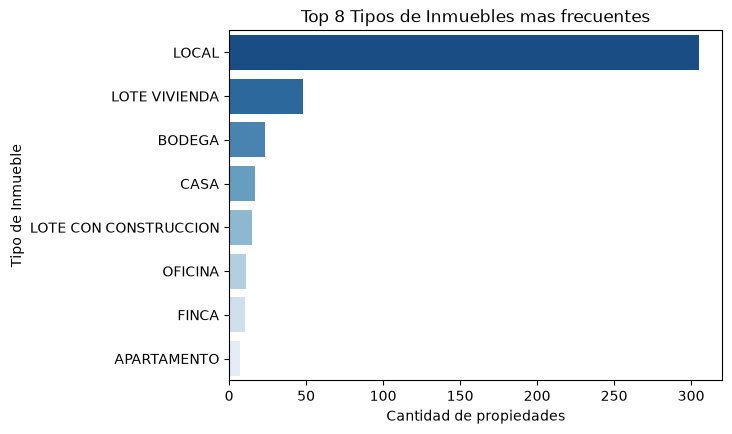

In [25]:
## Grafico 1.
## Distribucion por Tipo de Inmueble
plt.figure(figsize=(14, 10))
plt.subplot(2, 2, 1)
top_tipos = df['Tipo de Inmueble'].value_counts().head(8)
sns.barplot(x=top_tipos.values, y=top_tipos.index, palette='Blues_r', hue=top_tipos.index)
plt.title('Top 8 Tipos de Inmuebles mas frecuentes')
plt.xlabel('Cantidad de propiedades')

Text(0.5, 0, 'Cantidad de propiedades')

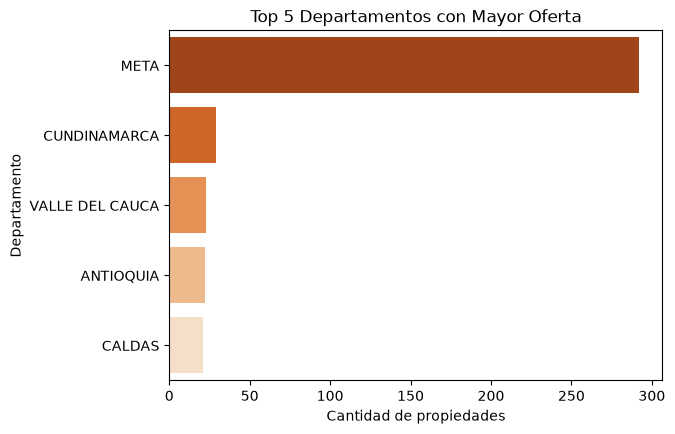

In [26]:
## Grafico 2.
## Top 5 Departamentos
plt.figure(figsize=(14, 10))
plt.subplot(2, 2, 2)
sns.barplot(x=top_departamentos.values, y=top_departamentos.index, palette='Oranges_r', hue=top_departamentos.index)
plt.title('Top 5 Departamentos con Mayor Oferta')
plt.xlabel('Cantidad de propiedades')

Text(0, 0.5, '')

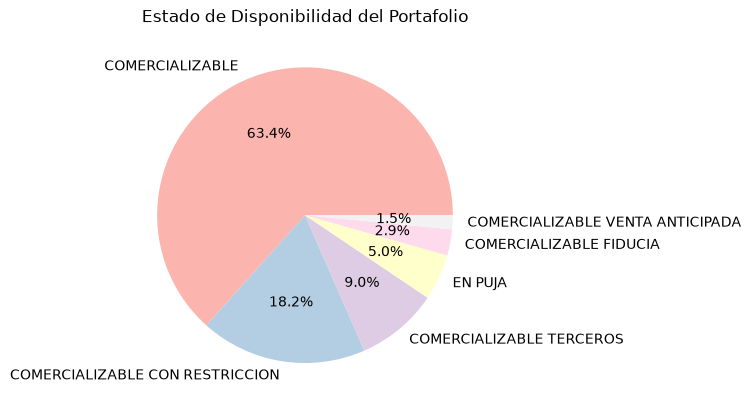

In [27]:
## Grafico 3
# Distribucion de Disponibilidad
df['Detalle Disponibilidad'].value_counts().plot(kind='pie', autopct='%1.1f%%', cmap='Pastel1')
plt.title('Estado de Disponibilidad del Portafolio')
plt.ylabel('')

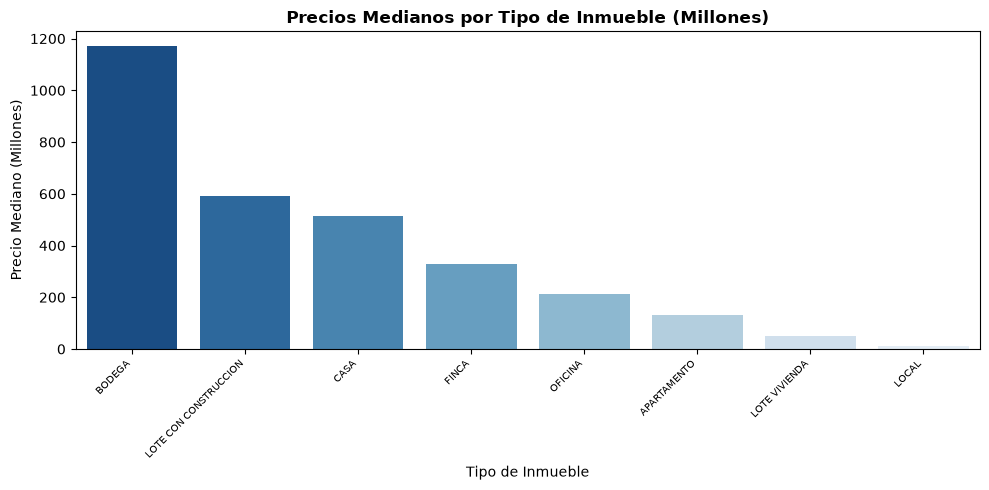

In [28]:
## Grafico 4
# Precios Medianos por Tipo de Inmueble
plt.figure(figsize=(10, 5))
df_filtrado = df[df['Tipo de Inmueble'].isin(top_tipos.index)]
mediana_tipo = df_filtrado.groupby('Tipo de Inmueble')['Precio_Millones'].median().sort_values(ascending=False)

sns.barplot(x=mediana_tipo.index, y=mediana_tipo.values, palette='Blues_r', hue=mediana_tipo.index)
plt.title('Precios Medianos por Tipo de Inmueble (Millones)', fontsize=12, fontweight='bold')
plt.xlabel('Tipo de Inmueble')
plt.ylabel('Precio Mediano (Millones)')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

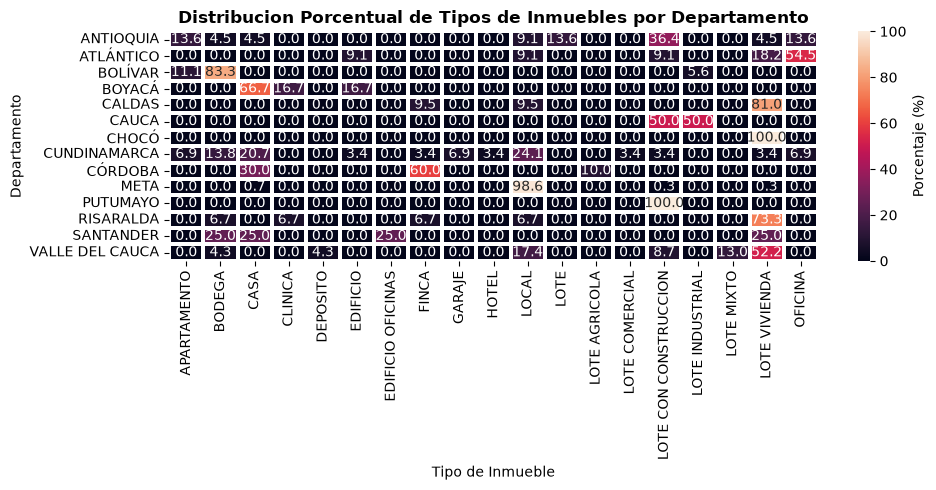

In [29]:
## Grafico 5
# Mapa de calor Departamento vs Tipo de Inmueble
plt.figure(figsize=(10, 5))
matriz_conteo = pd.crosstab(df['Departamento'], df['Tipo de Inmueble'], normalize='index') * 100
sns.heatmap(matriz_conteo,annot=True, fmt='.1f', linewidths=1.5, cbar_kws={'label': 'Porcentaje (%)'})
plt.title('Distribucion Porcentual de Tipos de Inmuebles por Departamento', fontsize=12, fontweight='bold')
plt.xlabel('Tipo de Inmueble')
plt.ylabel('Departamento')
plt.tight_layout()
plt.show()


In [31]:
df.describe()

,Codigo,Area Terreno,Area Construida,Precio,Precio_Millones
count,456.000000,4.560000e+02,456.000000,4.560000e+02,456.000000
mean,17984.425439,1.538463e+04,88.860746,6.387602e+08,638.760162
std,2001.656661,1.841005e+05,1146.133250,3.213308e+09,3213.307790
min,2575.000000,0.000000e+00,0.000000,4.650000e+06,4.650000
25%,18182.750000,0.000000e+00,0.000000,1.230500e+07,12.305000
50%,18328.500000,0.000000e+00,0.000000,1.587000e+07,15.870000
75%,18522.250000,0.000000e+00,0.000000,1.002651e+08,100.265077
max,19344.000000,3.217197e+06,22724.000000,4.523379e+10,45233.789820


In [78]:
porcentaje_terreno = df[df['Area Terreno'] > 0].shape[0] / df.shape[0] * 100
porcentaje_construida = df[df['Area Construida'] > 0].shape[0] / df.shape[0] * 100

print(f'Porcentaje de propiedades con área de terreno: {porcentaje_terreno:.2f}%')
print(f'Porcentaje de propiedades con área construida: {porcentaje_construida:.2f}%')
print(f'Total de propiedades: {df.shape[0]}')
print(f'Total de columnas: {df.shape[1]}')

Porcentaje de propiedades con área de terreno: 3.95%
Porcentaje de propiedades con área construida: 2.19%
Total de propiedades: 456
Total de columnas: 11


In [79]:
conteo_estrato = df['Estrato'].value_counts()
porcentaje_estrato = df['Estrato'].value_counts() / df.shape[0] * 100

print(f'Conteo de propiedades por estrato:\n{conteo_estrato}')
print(f'Porcentaje de propiedades por estrato:\n{porcentaje_estrato.round(2)}')

Conteo de propiedades por estrato:
Estrato
COMERCIAL     306
RURAL          40
UNO            21
TRES           19
CUATRO         19
INDUSTRIAL     16
DOS            16
CINCO          10
SEIS            9
Name: count, dtype: int64
Porcentaje de propiedades por estrato:
Estrato
COMERCIAL     67.11
RURAL          8.77
UNO            4.61
TRES           4.17
CUATRO         4.17
INDUSTRIAL     3.51
DOS            3.51
CINCO          2.19
SEIS           1.97
Name: count, dtype: float64
